# 05 - ML Temperature Prediction

Phase 1 benchmark for the residential thermal digital twin.

Goal: predict indoor temperature 1 hour ahead for:
- `temp_salon_c`
- `temp_kids_c`

Using:
- indoor temperature/humidity
- outdoor north/south temperatures/humidity
- thermal lag features
- time-cycle features
- solar proxy: `temp_out_2_n_c - temp_out_1_b_c`

This notebook uses the hourly dataset exported from the Home Assistant.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.multioutput import MultiOutputRegressor


## 1. Load hourly dataset

In [2]:
DATA_PATH = Path("../data/processed/TempHumData_27_4_26.csv")

# If running this notebook from a different location, update DATA_PATH accordingly.
df = pd.read_csv(DATA_PATH)

df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time").sort_index()

cutoff = "2026-02-22 17:00:00"
df = df[df.index >= cutoff]

print(df.shape)
display(df.head())
display(df.tail())

(1524, 8)


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n
time,,,,,,,,
2026-02-22 17:00:00,18.45,19.84,63.91,55.66,9.89,66.82,17.01,55.45
2026-02-22 18:00:00,19.33,20.04,63.81,56.66,9.23,70.83,11.63,63.32
2026-02-22 19:00:00,19.07,19.65,65.78,60.08,8.89,70.79,10.33,66.01
2026-02-22 20:00:00,19.44,19.84,66.32,61.13,8.64,71.44,9.66,68.00
2026-02-22 21:00:00,19.26,19.54,65.34,61.40,8.44,75.14,9.39,71.99


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n
time,,,,,,,,
2026-04-27 01:00:00,20.5,20.5,48.06,45.62,18.49,34.92,17.34,36.65
2026-04-27 02:00:00,20.5,20.5,47.60,46.10,17.97,36.76,16.76,38.86
2026-04-27 03:00:00,20.5,20.5,47.60,46.10,17.49,39.41,16.29,41.62
2026-04-27 04:00:00,20.5,20.5,47.60,47.02,17.03,42.39,15.92,44.46
2026-04-27 05:00:00,20.5,20.5,47.60,47.10,16.72,44.56,15.65,46.76


## 2. Quick data quality check

In [3]:
print("Date range:", df.index.min(), "→", df.index.max())
print("\nMissing values:")
display(df.isna().sum())

# Verify hourly spacing
time_diffs = df.index.to_series().diff().dropna()
display(time_diffs.value_counts().head())


Date range: 2026-02-22 17:00:00 → 2026-04-27 05:00:00

Missing values:


temp_salon_c      0
temp_kids_c       4
hum_salon         0
hum_kids          4
temp_out_1_b_c    0
hum_out_1_b       0
temp_out_2_n_c    0
hum_out_2_n       0
dtype: int64

0 days 01:00:00    1522
0 days 02:00:00       1
Name: time, dtype: int64

## 3. Clean and interpolate small gaps

In [4]:
# Hourly grid, in case any timestamps are missing
df = df.resample("1h").mean()

# Interpolate short gaps only. Long initial gaps in outdoor sensors remain NaN and will be dropped later.
df = df.interpolate(methods="time", limit=4)

# Optional: add mean outdoor conditions if both sides exist
df["temp_out_mean_c"] = df[["temp_out_1_b_c", "temp_out_2_n_c"]].mean(axis=1)
df["hum_out_mean"] = df[["hum_out_1_b", "hum_out_2_n"]].mean(axis=1)

# Solar / orientation proxy: south-facing outdoor sensor minus north-facing outdoor sensor.
# Confirm which outdoor sensor is north/south in your setup before interpreting physically.
df["solar_proxy_temp_delta"] = df["temp_out_2_n_c"] - df["temp_out_1_b_c"]

display(df.tail())

,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,temp_out_mean_c,hum_out_mean,solar_proxy_temp_delta
time,,,,,,,,,,,
2026-04-27 01:00:00,20.5,20.5,48.06,45.62,18.49,34.92,17.34,36.65,17.915,35.785,-1.15
2026-04-27 02:00:00,20.5,20.5,47.60,46.10,17.97,36.76,16.76,38.86,17.365,37.810,-1.21
2026-04-27 03:00:00,20.5,20.5,47.60,46.10,17.49,39.41,16.29,41.62,16.890,40.515,-1.20
2026-04-27 04:00:00,20.5,20.5,47.60,47.02,17.03,42.39,15.92,44.46,16.475,43.425,-1.11
2026-04-27 05:00:00,20.5,20.5,47.60,47.10,16.72,44.56,15.65,46.76,16.185,45.660,-1.07


## 4. Feature Engineering

In [5]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    hour = out.index.hour
    dayofyear = out.index.dayofyear

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    out["doy_sin"] = np.sin(2 * np.pi * dayofyear / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * dayofyear / 365.25)

    out["is_weekend"] = (out.index.dayofweek >= 5).astype(int)
    return out


def add_lag_features(data, columns, lags):
    out = data.copy()
    for col in columns:
        for lag in lags:
            out[f"{col}_lag_{lag}h"] = out[col].shift(lag)
    return out


def add_rolling_features(data: pd.DataFrame, columns, windows) -> pd.DataFrame:
    out = data.copy()
    for col in columns:
        for window in windows:
            out[f"{col}_roll_mean_{window}h"] = out[col].rolling(window).mean()
            out[f"{col}_roll_std_{window}h"] = out[col].rolling(window).std()
    return out

In [6]:
feat = df.copy()
horizon = 1

feat["temp_diff_south"] = feat["temp_out_2_n_c"] - feat["temp_salon_c"]
feat["temp_diff_north"] = feat["temp_out_1_b_c"] - feat["temp_salon_c"]

feat["temp_salon_c_target_plus_1h"] = feat["temp_salon_c"].shift(-horizon)
feat["temp_kids_c_target_plus_1h"] = feat["temp_kids_c"].shift(-horizon)

# 3. Define target_cols AFTER have been created
target_cols = [
    "temp_salon_c_target_plus_1h",
    "temp_kids_c_target_plus_1h",
]

# 4. Sanity check: should return True
print("Targets exist in df_feat:")
for col in target_cols:
    print(col, col in feat.columns)

Targets exist in df_feat:
temp_salon_c_target_plus_1h True
temp_kids_c_target_plus_1h True


In [7]:
targets = ["temp_salon_c", "temp_kids_c"]
# base_series_for_lags = [
#     "temp_salon_c",
#     "temp_kids_c",
#     "temp_out_1_b_c",
#     "temp_out_2_n_c",
#     "temp_out_mean_c",
#     "solar_proxy_temp_delta",
# ]

horizon_hours = 1

feat = add_time_features(feat)
lag_cols = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "temp_out_mean_c",
    "solar_proxy_temp_delta",
]

feat = add_lag_features(feat, columns=lag_cols, lags=[1, 2, 3, 6, 12, 24, 48])

feat = add_rolling_features(
    feat,
    columns=["temp_salon_c", "temp_kids_c"],
    windows=[2, 3, 6, 12, 24, 48]
)

# for target in targets:
#     feat[f"target_{target}_plus_{horizon_hours}h"] = feat[target].shift(-horizon_hours)

feat = feat.dropna()

print(feat.shape)
display(feat.head())

# 7. Sanity check again
print("Columns with target:")
print([c for c in feat.columns if "target" in c])


(1476, 86)


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,temp_out_mean_c,hum_out_mean,...,temp_kids_c_roll_mean_3h,temp_kids_c_roll_std_3h,temp_kids_c_roll_mean_6h,temp_kids_c_roll_std_6h,temp_kids_c_roll_mean_12h,temp_kids_c_roll_std_12h,temp_kids_c_roll_mean_24h,temp_kids_c_roll_std_24h,temp_kids_c_roll_mean_48h,temp_kids_c_roll_std_48h
time,,,,,,,,,,,,,,,,,,,,,
2026-02-24 17:00:00,17.30,19.10,64.40,56.07,15.75,53.24,19.64,41.33,17.695,47.285,...,19.110000,0.305123,18.803333,0.580781,18.245833,0.731840,18.560833,0.712887,18.691250,0.749030
2026-02-24 18:00:00,17.31,18.55,64.92,57.61,14.83,55.83,16.20,49.31,15.515,52.570,...,19.023333,0.440038,18.918333,0.395344,18.283333,0.735210,18.492917,0.624030,18.660208,0.722344
2026-02-24 19:00:00,18.29,19.28,68.54,58.50,14.24,59.77,15.01,55.48,14.625,57.625,...,18.976667,0.380307,19.063333,0.324879,18.386667,0.783458,18.485417,0.612883,18.652500,0.713477
2026-02-24 20:00:00,18.83,19.78,68.50,58.88,13.76,62.90,14.31,59.72,14.035,61.310,...,19.203333,0.618574,19.156667,0.439211,18.588333,0.806292,18.508333,0.651030,18.651250,0.711401
2026-02-24 21:00:00,18.56,19.64,69.60,61.37,13.36,63.33,13.74,60.62,13.550,61.975,...,19.566667,0.257941,19.295000,0.438896,18.766667,0.779922,18.530833,0.681009,18.653333,0.714200


Columns with target:
['temp_salon_c_target_plus_1h', 'temp_kids_c_target_plus_1h']


In [8]:
print(feat.columns)

Index(['temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids',
       'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n',
       'temp_out_mean_c', 'hum_out_mean', 'solar_proxy_temp_delta',
       'temp_diff_south', 'temp_diff_north', 'temp_salon_c_target_plus_1h',
       'temp_kids_c_target_plus_1h', 'hour_sin', 'hour_cos', 'doy_sin',
       'doy_cos', 'is_weekend', 'temp_salon_c_lag_1h', 'temp_salon_c_lag_2h',
       'temp_salon_c_lag_3h', 'temp_salon_c_lag_6h', 'temp_salon_c_lag_12h',
       'temp_salon_c_lag_24h', 'temp_salon_c_lag_48h', 'temp_kids_c_lag_1h',
       'temp_kids_c_lag_2h', 'temp_kids_c_lag_3h', 'temp_kids_c_lag_6h',
       'temp_kids_c_lag_12h', 'temp_kids_c_lag_24h', 'temp_kids_c_lag_48h',
       'temp_out_1_b_c_lag_1h', 'temp_out_1_b_c_lag_2h',
       'temp_out_1_b_c_lag_3h', 'temp_out_1_b_c_lag_6h',
       'temp_out_1_b_c_lag_12h', 'temp_out_1_b_c_lag_24h',
       'temp_out_1_b_c_lag_48h', 'temp_out_2_n_c_lag_1h',
       'temp_out_2_n_c_lag_2h', 'tem

## 5. Train/test split — chronological, not random

In [9]:
# 8. X = all except targets
X = feat.drop(columns=target_cols)

# 9. y = Only targets
y = feat[target_cols]

print("X columns sample:")
print(X.columns[:10].tolist())

print("y columns:")
print(y.columns.tolist())

split_idx = int(len(feat) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train:", X_train.index.min(), "→", X_train.index.max(), X_train.shape)
print("Test:", X_test.index.min(), "→", X_test.index.max(), X_test.shape)


X columns sample:
['temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids', 'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n', 'temp_out_mean_c', 'hum_out_mean']
y columns:
['temp_salon_c_target_plus_1h', 'temp_kids_c_target_plus_1h']
Train: 2026-02-24 17:00:00 → 2026-04-14 20:00:00 (1180, 84)
Test: 2026-04-14 21:00:00 → 2026-04-27 04:00:00 (296, 84)


## 6. Baseline: persistence model

Persistence means: the best guess for `T(t+1h)` is simply `T(t)`.

In [10]:
baseline_map = {
    "temp_salon_c_target_plus_1h": "temp_salon_c",
    "temp_kids_c_target_plus_1h": "temp_kids_c",
}

for target_col, current_col in baseline_map.items():
    y_true = y_test[target_col]
    y_pred = X_test[current_col]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)

    print(f"Persistence {target_col}: MAE={mae:.3f} °C | RMSE={rmse:.3f} °C")

Persistence temp_salon_c_target_plus_1h: MAE=0.052 °C | RMSE=0.106 °C
Persistence temp_kids_c_target_plus_1h: MAE=0.064 °C | RMSE=0.111 °C


## 7. Random Forest model

In [11]:
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
rf_pred = pd.DataFrame(rf.predict(X_test), index=X_test.index, columns=target_cols)

for col in target_cols:
    mae = mean_absolute_error(y_test[col], rf_pred[col])
    rmse = mean_squared_error(y_test[col], rf_pred[col], squared=False)
    print(f"Random Forest {col}: MAE={mae:.3f} °C | RMSE={rmse:.3f} °C")


Random Forest temp_salon_c_target_plus_1h: MAE=0.322 °C | RMSE=0.512 °C
Random Forest temp_kids_c_target_plus_1h: MAE=0.257 °C | RMSE=0.410 °C


## 9. Plot predictions

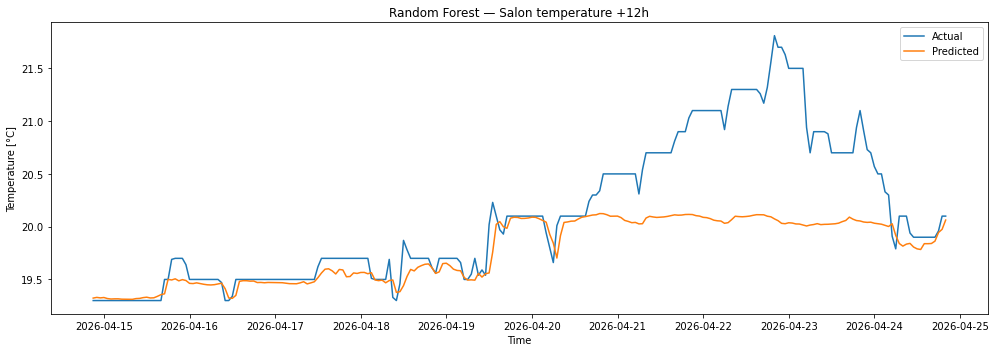

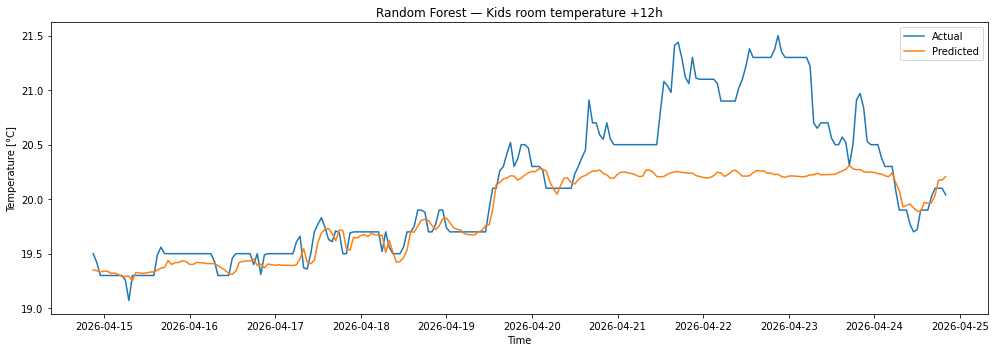

In [12]:
def plot_prediction(y_true, y_pred, target_col, title, n=240):
    plt.figure(figsize=(14, 5))
    plt.plot(y_true[target_col].iloc[:n].index, y_true[target_col].iloc[:n], label="Actual")
    plt.plot(y_pred[target_col].iloc[:n].index, y_pred[target_col].iloc[:n], label="Predicted")
    plt.title(title)
    plt.ylabel("Temperature [°C]")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_prediction(y_test, rf_pred, target_cols[0], "Random Forest — Salon temperature +12h")
plot_prediction(y_test, rf_pred, target_cols[1], "Random Forest — Kids room temperature +12h")


## 10. Feature importance

In [13]:
# Built-in feature importance for Random Forest.

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

temp_salon_c                      0.548013
temp_kids_c                       0.323761
temp_salon_c_roll_mean_2h         0.005540
temp_kids_c_roll_std_2h           0.005144
temp_salon_c_roll_std_2h          0.005104
temp_kids_c_roll_mean_24h         0.004796
temp_kids_c_lag_1h                0.004552
temp_salon_c_roll_mean_3h         0.003844
temp_kids_c_roll_mean_2h          0.003642
temp_salon_c_lag_1h               0.003338
solar_proxy_temp_delta_lag_48h    0.002878
temp_out_2_n_c_lag_48h            0.002490
solar_proxy_temp_delta_lag_24h    0.002270
temp_kids_c_roll_mean_12h         0.002218
hour_sin                          0.002205
dtype: float64


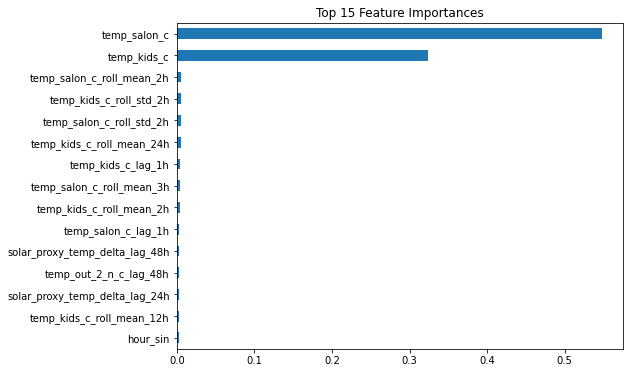

In [14]:
plt.figure(figsize=(8,6))
feature_importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

# LSTM sequence model

### 1. Imports first

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


c:\users\sotdo\appdata\local\programs\python\python37\lib\site-packages\requests\__init__.py:91: RequestsDependencyWarning: urllib3 (1.26.7) or chardet (3.0.4) doesn't match a supported version!
  RequestsDependencyWarning)


### 2. Create a new DataFrame specifically for LSTM

In [16]:
# Use initial hourly df, not the one for RF
lstm_df = df.copy()

# Time features
lstm_df = add_time_features(lstm_df)

# Physics-inspired features
lstm_df["solar_proxy_temp_delta"] = (
    lstm_df["temp_out_2_n_c"] - lstm_df["temp_out_1_b_c"]
)

lstm_df["temp_out_mean_c"] = (
    lstm_df["temp_out_2_n_c"] - lstm_df["temp_out_1_b_c"]
) / 2

lstm_df["salon_outdoor_delta"] = (
    lstm_df["temp_out_mean_c"] - lstm_df["temp_salon_c"]
)

lstm_df["kids_outdoor_delta"] = (
    lstm_df["temp_out_mean_c"] - lstm_df["temp_kids_c"]
)

lstm_df = lstm_df.dropna()

### 3. Define features/targets

In [17]:
lstm_features = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "hum_salon",
    "hum_kids",
    "hum_out_1_b",
    "hum_out_2_n",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "solar_proxy_temp_delta",
    "temp_out_mean_c",
    "salon_outdoor_delta",
    "kids_outdoor_delta",
]

lstm_targets = [
    "temp_salon_c",
    "temp_kids_c",
]

### 4. Sequence creator

In [18]:
def create_lstm_sequences(df, feature_cols, target_cols, seq_len=24, horizon=12):
    X, y, target_times = [], [], []
    
    feature_values = df[feature_cols].values
    target_values = df[target_cols].values
    index_values = df.index

    for i in range(len(df) - seq_len - horizon + 1):
        X.append(feature_values[i:i + seq_len])
        y.append(target_values[i + seq_len + horizon - 1])
        target_times.append(index_values[i + seq_len + horizon - 1])
        
    return np.array(X), np.array(y), pd.DatetimeIndex(target_times)


### 5. Scaling

In [19]:
seq_len = 24
horizon = 12

split_idx_raw = int(len(lstm_df) * 0.8)

train_df = lstm_df.iloc[:split_idx_raw].copy()
test_df = lstm_df.iloc[split_idx_raw - seq_len - horizon + 1:].copy()

In [20]:
# Fit only on train dataset
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_df[lstm_features])
target_scaler.fit(train_df[lstm_targets])

train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[lstm_features] = feature_scaler.transform(train_df[lstm_features])
test_scaled[lstm_features] = feature_scaler.transform(test_df[lstm_features])

train_scaled[lstm_targets] = target_scaler.transform(train_df[lstm_targets])
test_scaled[lstm_targets] = target_scaler.transform(test_df[lstm_targets])


### 6. Create sequences

In [21]:
X_train_lstm, y_train_lstm, train_times = create_lstm_sequences(
    train_scaled,
    lstm_features,
    lstm_targets,
    seq_len=seq_len,
    horizon=horizon
)

X_test_lstm, y_test_lstm, test_times = create_lstm_sequences(
    test_scaled,
    lstm_features,
    lstm_targets,
    seq_len=seq_len,
    horizon=horizon
)

print("X_train:", X_train_lstm.shape)
print("y_train:", y_train_lstm.shape)
print("X_test:", X_test_lstm.shape)
print("y_test:", y_test_lstm.shape)

X_train: (1185, 24, 16)
y_train: (1185, 2)
X_test: (305, 24, 16)
y_test: (305, 2)


In [22]:
model_lstm = Sequential([
    LSTM(32, input_shape=(seq_len, len(lstm_features))),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(len(lstm_targets))
])

model_lstm.compile(
    optimizer="adam",
    loss="mae"
)

model_lstm.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 32)                6272      
_________________________________________________________________
dropout (Dropout)            (None, 32)                0         
_________________________________________________________________
dense (Dense)                (None, 16)                528       
_________________________________________________________________
dense_1 (Dense)              (None, 2)                 34        
Total params: 6,834
Trainable params: 6,834
Non-trainable params: 0
_________________________________________________________________


In [23]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
75/75 [==============================] - 3s 40ms/step - loss: 0.5925 - val_loss: 0.6535
Epoch 2/100
75/75 [==============================] - ETA: 0s - loss: 0.440 - 2s 23ms/step - loss: 0.4404 - val_loss: 0.4990
Epoch 3/100
75/75 [==============================] - 2s 24ms/step - loss: 0.4123 - val_loss: 0.4777
Epoch 4/100
75/75 [==============================] - 2s 24ms/step - loss: 0.4032 - val_loss: 0.4333
Epoch 5/100
75/75 [==============================] - 2s 24ms/step - loss: 0.3862 - val_loss: 0.4461
Epoch 6/100
75/75 [==============================] - 2s 24ms/step - loss: 0.3801 - val_loss: 0.5037
Epoch 7/100
75/75 [==============================] - 2s 25ms/step - loss: 0.3735 - val_loss: 0.5048
Epoch 8/100
75/75 [==============================] - 2s 23ms/step - loss: 0.3534 - val_loss: 0.4645
Epoch 9/100
75/75 [==============================] - 2s 23ms/step - loss: 0.3466 - val_loss: 0.5199
Epoch 10/100
75/75 [==============================] - 2s 26ms/step - loss: 0

### Predictions and Inverse scaling

In [24]:
pred_scaled = model_lstm. predict(X_test_lstm)

pred_lstm = target_scaler.inverse_transform(pred_scaled)
actual_lstm = target_scaler.inverse_transform(y_test_lstm)

pred_lstm_df = pd.DataFrame(
    pred_lstm,
    index=test_times,
    columns=[f"pred_{c}_plus_{horizon}h" for c in lstm_targets]
)

actual_lstm_df = pd.DataFrame(
    actual_lstm,
    index=test_times,
    columns=[f"actual_{c}_plus_{horizon}h" for c in lstm_targets]
)


In [25]:
for i, target in enumerate(lstm_targets):
    y_true = actual_lstm[:, i]
    y_pred = pred_lstm[:, i]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    
    print(f"LSTM {target} + {horizon}h: MAE={mae:.3f} °C | RMSE={rmse:.3f} °C")


LSTM temp_salon_c + 12h: MAE=0.357 °C | RMSE=0.478 °C
LSTM temp_kids_c + 12h: MAE=0.351 °C | RMSE=0.435 °C


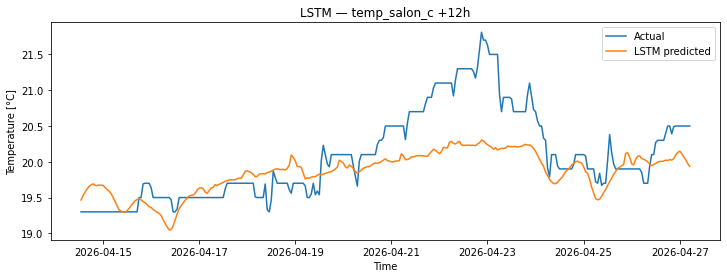

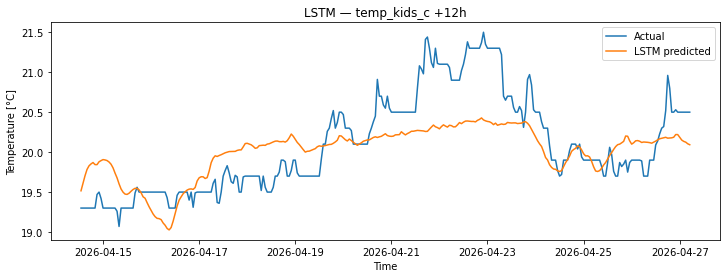

In [26]:
for i, target in enumerate(lstm_targets):
    plt.figure(figsize=(12, 4))
    plt.plot(test_times, actual_lstm[:, i], label="Actual")
    plt.plot(test_times, pred_lstm[:, i], label="LSTM predicted")
    plt.title(f"LSTM — {target} +{horizon}h")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    plt.show()

## 8. Physics-informed LSTM: predicting temperature change (ΔT)

In [27]:
# Physics-informed LSTM setup
# We start fresh from the clean hourly dataframe, not from RF features or previous LSTM tensors.

phys_df = df.copy()

# Add time features
phys_df = add_time_features(phys_df)
print(phys_df.columns)

# Physics-inspired explanatory variables
phys_df["outdoor_mean_c"] = (
    phys_df["temp_out_1_b_c"] + phys_df["temp_out_2_n_c"]
) / 2

phys_df["solar_proxy_temp_delta"] = (
    phys_df["temp_out_2_n_c"] - phys_df["temp_out_1_b_c"]
)

phys_df["salon_heat_loss_driver"] = (
    phys_df["outdoor_mean_c"] - phys_df["temp_salon_c"]
)

phys_df["kids_heat_loss_driver"] = (
    phys_df["outdoor_mean_c"] - phys_df["temp_kids_c"]
)

# Accumulated / smoothed external forcing
phys_df["solar_proxy_roll_6h"] = (
    phys_df["solar_proxy_temp_delta"].rolling(6).mean()
)

phys_df["solar_proxy_roll_12h"] = (
    phys_df["solar_proxy_temp_delta"].rolling(21).mean()
)

phys_df["outdoor_mean_roll_12h"] = (
    phys_df["outdoor_mean_c"].rolling(12).mean()
)

phys_df = phys_df.dropna()

print(phys_df.shape)
phys_df.head()


Index(['temp_salon_c', 'temp_kids_c', 'hum_salon', 'hum_kids',
       'temp_out_1_b_c', 'hum_out_1_b', 'temp_out_2_n_c', 'hum_out_2_n',
       'temp_out_mean_c', 'hum_out_mean', 'solar_proxy_temp_delta', 'hour_sin',
       'hour_cos', 'doy_sin', 'doy_cos', 'is_weekend'],
      dtype='object')
(1505, 22)


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,temp_out_mean_c,hum_out_mean,...,hour_cos,doy_sin,doy_cos,is_weekend,outdoor_mean_c,salon_heat_loss_driver,kids_heat_loss_driver,solar_proxy_roll_6h,solar_proxy_roll_12h,outdoor_mean_roll_12h
time,,,,,,,,,,,,,,,,,,,,,
2026-02-23 13:00:00,17.59,18.60,59.43,50.02,13.56,48.81,16.46,42.86,15.010,45.835,...,-0.965926,0.80098,0.598691,0,15.010,-2.580,-3.590,0.798333,1.159048,10.123333
2026-02-23 14:00:00,17.70,19.31,60.76,53.32,14.24,45.72,17.33,39.04,15.785,42.380,...,-0.866025,0.80098,0.598691,0,15.785,-1.915,-3.525,1.361667,0.967143,10.790417
2026-02-23 15:00:00,17.70,19.58,62.05,52.52,14.43,46.50,19.24,36.65,16.835,41.575,...,-0.707107,0.80098,0.598691,0,16.835,-0.865,-2.745,2.275000,1.081905,11.543333
2026-02-23 16:00:00,17.70,19.74,61.10,51.13,14.01,50.16,21.21,35.55,17.610,42.855,...,-0.500000,0.80098,0.598691,0,17.610,-0.090,-2.130,3.498333,1.356190,12.327083
2026-02-23 17:00:00,17.88,19.75,61.50,53.01,13.00,55.39,20.00,38.42,16.500,46.905,...,-0.258819,0.80098,0.598691,0,16.500,-1.380,-3.250,4.513333,1.640952,13.002083


In [28]:
# Instead of predicting abso;ute future temperature,
# we predict temperature change over the forecast horizon.

phys_horizon = 12

phys_df["delta_temp_salon_c"] = (
    phys_df["temp_salon_c"].shift(-phys_horizon) - phys_df["temp_salon_c"]
)

phys_df["delta_temp_kids_c"] = (
    phys_df["temp_kids_c"].shift(-phys_horizon) - phys_df["temp_kids_c"]
)

phys_df = phys_df.dropna()

phys_features = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_1_b_c",
    "temp_out_2_n_c",
    "hum_salon",
    "hum_kids",
    "hum_out_1_b",
    "hum_out_2_n",

    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    "outdoor_mean_c",
    "solar_proxy_temp_delta",
    "salon_heat_loss_driver",
    "kids_heat_loss_driver",
    "solar_proxy_roll_6h",
    "solar_proxy_roll_12h",
    "outdoor_mean_roll_12h",
]

phys_targets = [
    "delta_temp_salon_c",
    "delta_temp_kids_c",
]

print("Physics-informed features:", len(phys_features))
print("Physics-informed targets:", phys_targets)

Physics-informed features: 19
Physics-informed targets: ['delta_temp_salon_c', 'delta_temp_kids_c']


In [29]:
# Sequence creation for physics-informed LSTM

phys_seq_len = 24

X_phys, y_phys, phys_target_times = create_lstm_sequences(
    phys_df,
    feature_cols=phys_features,
    target_cols=phys_targets,
    seq_len=phys_seq_len,
    horizon=1
)

print("X_phys:", X_phys.shape)
print("y_phys:", y_phys.shape)
print("target times:", phys_target_times[0], "→", phys_target_times[-1])

X_phys: (1469, 24, 19)
y_phys: (1469, 2)
target times: 2026-02-24 13:00:00 → 2026-04-26 17:00:00


In [31]:
# Chronoligical split
phys_split = int(len(X_phys) * 0.8)

X_phys_train_raw = X_phys[:phys_split]
X_phys_test_raw = X_phys[phys_split:]

y_phys_train_raw = y_phys[:phys_split]
y_phys_test_raw = y_phys[phys_split:]

phys_test_times = phys_target_times[phys_split:]

print("Train:", X_phys_train_raw.shape, y_phys_train_raw.shape)
print("Test:", X_phys_test_raw.shape, y_phys_test_raw.shape)


Train: (1175, 24, 19) (1175, 2)
Test: (294, 24, 19) (294, 2)


In [32]:
# Scaling
# For 3D LSTM input, we reshape temporarily to 2D for scaler fitting.

from sklearn.preprocessing import StandardScaler

n_train, seq_len_train, n_features = X_phys_train_raw.shape
n_test = X_phys_test_raw.shape[0]

phys_feature_scaler = StandardScaler()
phys_target_scaler = StandardScaler()

X_train_2d = X_phys_train_raw.reshape(-1, n_features)
X_test_2d = X_phys_test_raw.reshape(-1, n_features)

X_phys_train_scaled = phys_feature_scaler.fit_transform(X_train_2d).reshape(
    n_train, seq_len_train, n_features
)

X_phys_test_scaled = phys_feature_scaler.transform(X_test_2d).reshape(
    n_test, seq_len_train, n_features
)

y_phys_train_scaled = phys_target_scaler.fit_transform(y_phys_train_raw)
y_phys_test_scaled = phys_target_scaler.transform(y_phys_test_raw)

print("Scaled X train:", X_phys_train_scaled.shape)
print("Scaled y train:", y_phys_train_scaled.shape)


Scaled X train: (1175, 24, 19)
Scaled y train: (1175, 2)


In [33]:
# Physics-informed LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

phys_lstm_model = Sequential([
    LSTM(32, input_shape=(phys_seq_len, len(phys_features))),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(len(phys_targets))
])

phys_lstm_model.compile(
    optimizer="adam",
    loss="mae"
)

phys_lstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (None, 32)                6656      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_3 (Dense)              (None, 2)                 34        
Total params: 7,218
Trainable params: 7,218
Non-trainable params: 0
_________________________________________________________________


In [35]:
phys_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

phys_history = phys_lstm_model.fit(
    X_phys_train_scaled,
    y_phys_train_scaled,
    validation_data=(X_phys_test_scaled, y_phys_test_scaled),
    epochs=100,
    batch_size=16,
    callbacks=[phys_early_stop],
    verbose=1
)

Epoch 1/100
74/74 [==============================] - 2s 21ms/step - loss: 0.6914 - val_loss: 0.2599
Epoch 2/100
74/74 [==============================] - 1s 14ms/step - loss: 0.5285 - val_loss: 0.2314
Epoch 3/100
74/74 [==============================] - 1s 14ms/step - loss: 0.4599 - val_loss: 0.2255
Epoch 4/100
74/74 [==============================] - 1s 12ms/step - loss: 0.4385 - val_loss: 0.2237
Epoch 5/100
74/74 [==============================] - 1s 13ms/step - loss: 0.4152 - val_loss: 0.2198
Epoch 6/100
74/74 [==============================] - 1s 12ms/step - loss: 0.4082 - val_loss: 0.2170
Epoch 7/100
74/74 [==============================] - 1s 9ms/step - loss: 0.3968 - val_loss: 0.2177
Epoch 8/100
74/74 [==============================] - 1s 15ms/step - loss: 0.3933 - val_loss: 0.2299
Epoch 9/100
74/74 [==============================] - 1s 15ms/step - loss: 0.3774 - val_loss: 0.2458
Epoch 10/100
74/74 [==============================] - 1s 14ms/step - loss: 0.3758 - val_loss: 0.2308


In [37]:
# Predict scaled ΔT
phys_pred_delta_scaled = phys_lstm_model.predict(X_phys_test_scaled)

# Convert predicted and actual ΔΤ back to °C
phys_pred_delta = phys_target_scaler.inverse_transform(phys_pred_delta_scaled)
phys_actual_delta = phys_target_scaler.inverse_transform(y_phys_test_scaled)

print("Predicted ΔT shape:", phys_pred_delta.shape)
print("Actual ΔT shape:", phys_actual_delta.shape)

Predicted ΔT shape: (294, 2)
Actual ΔT shape: (294, 2)
